In [2]:
# ==========================================
# LAB 4: RNN vs LSTM vs GRU (IMDB Dataset)
# ==========================================

In [17]:

# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Embedding
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# ------------------------------------------
# 2. Load Dataset
# ------------------------------------------
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("\n===== DATASET INFO =====")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Sample review (encoded):", X_train[0])
print("Sample label:", y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

===== DATASET INFO =====
Training samples: 25000
Testing samples : 25000
Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226,

In [ ]:
# ------------------------------------------
# sample view - decode reviews  
# ------------------------------------------

# Get word index
word_index = imdb.get_word_index()

# Reverse mapping (index → word)
reverse_word_index = {value: key for key, value in word_index.items()}

# Improved decode function
def decode_review(encoded_review):
    words = []
    for i in encoded_review:
        idx = i - 3  # adjust for special tokens
        
        if idx in reverse_word_index:
            words.append(reverse_word_index[idx])
        elif i == 0:
            continue              # skip padding
        elif i == 1:
            words.append("<START>")
        elif i == 2:
            words.append("<UNK>")
        else:
            words.append("<UNK>")
    
    return ' '.join(words)

# Show reviews (3 to 7)
for i in range(3, 8):
    print(f"\nReview {i+1}:")
    print(decode_review(X_train[i]))
    print("Label:", y_train[i])


Review 4:
the death of his parents br br he is pulled to make a last <UNK> journey to the <UNK> of one of <UNK> most <UNK> mountains can the truth be told or is it all in stories br br in this story about stories we <UNK> bloody battles <UNK> lovers the <UNK> of old and the sometimes more <UNK> <UNK> of accepted truth in doing so we each connect with <UNK> as he lives the story of his own life br br <UNK> the <UNK> <UNK> is probably the most honest <UNK> and genuinely beautiful film of scotland ever made like <UNK> i got slightly annoyed with the <UNK> of hanging stories on more stories but also like <UNK> i <UNK> this once i saw the <UNK> picture ' forget the box office <UNK> of braveheart and its like you might even <UNK> the <UNK> famous <UNK> of the wicker man to see a film that is true to scotland this one is probably unique if you maybe <UNK> on it deeply enough you might even re <UNK> the power of storytelling and the age old question of whether there are some truths that canno

In [28]:

# ------------------------------------------
# 3. DATASET ANALYSIS
# ------------------------------------------

# Review lengths
train_lengths = [len(x) for x in X_train]

print("\n===== DATA ANALYSIS =====")
print("Average review length:", int(np.mean(train_lengths)))
print("Max review length    :", max(train_lengths))
print("Min review length    :", min(train_lengths))



===== DATA ANALYSIS =====
Average review length: 200
Max review length    : 200
Min review length    : 200


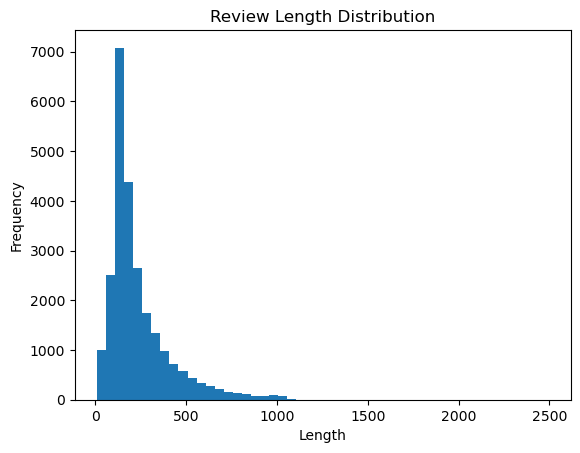

In [6]:

# Plot review length distribution
plt.figure()
plt.hist(train_lengths, bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()


In [7]:

# Class distribution
positive = sum(y_train)
negative = len(y_train) - positive

print("\nClass Distribution:")
print("Positive reviews:", positive)
print("Negative reviews:", negative)



Class Distribution:
Positive reviews: 12500
Negative reviews: 12500


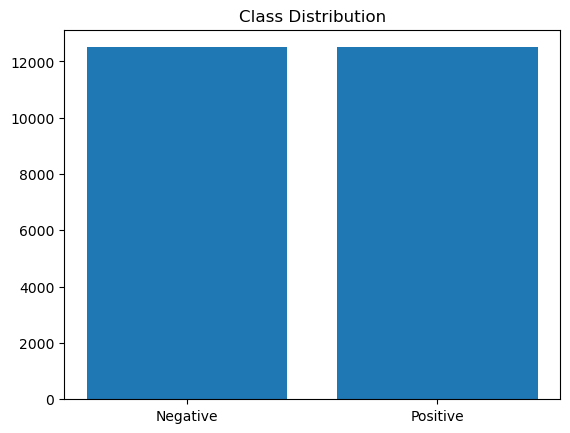

In [8]:

# Plot class distribution
plt.figure()
plt.bar(["Negative", "Positive"], [negative, positive])
plt.title("Class Distribution")
plt.show()


In [9]:

# ------------------------------------------
# 4. Preprocessing
# ------------------------------------------
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

print("\nData Preprocessed (Padding Applied)")



Data Preprocessed (Padding Applied)


In [18]:

# ------------------------------------------
# 5. Build Model Function
# ------------------------------------------
def build_model(model_type):
    model = Sequential()

    model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length=max_length))

    if model_type == "RNN":
        model.add(SimpleRNN(32))
    elif model_type == "LSTM":
        model.add(LSTM(32))
    elif model_type == "GRU":
        model.add(GRU(32))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [19]:

# ------------------------------------------
# 6. Train Models
# ------------------------------------------
models = ["RNN", "LSTM", "GRU"]
history = {}
training_time = {}

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

for m in models:
    print(f"\n===== Training {m} =====")

    model = build_model(m)

    start = time.time()

    history[m] = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=128,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    end = time.time()

    training_time[m] = end - start



===== Training RNN =====
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 85ms/step - accuracy: 0.6248 - loss: 0.6745 - val_accuracy: 0.7660 - val_loss: 0.5236
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 22s 112ms/step - accuracy: 0.8120 - loss: 0.4314 - val_accuracy: 0.8274 - val_loss: 0.4073
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 81ms/step - accuracy: 0.8728 - loss: 0.3201 - val_accuracy: 0.8396 - val_loss: 0.3813
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9171 - loss: 0.2294 - val_accuracy: 0.8447 - val_loss: 0.3798
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.9506 - loss: 0.1503 - val_accuracy: 0.8365 - val_loss: 0.4091
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.9750 - loss: 0.0887 - val_accuracy: 0.8356 - val_loss: 0.4444
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9874 - loss: 0.0505 - val_accuracy: 0.8344 - val_loss: 0.5026

===== Training LSTM =====
Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━

In [20]:

# ------------------------------------------
# 7. RESULT COMPARISON
# ------------------------------------------
print("\n========= FINAL RESULTS =========")

for m in models:
    train_acc = history[m].history['accuracy'][-1]
    val_acc = history[m].history['val_accuracy'][-1]
    loss = history[m].history['loss'][-1]

    print(f"\n{m}:")
    print(f"   Train Accuracy : {train_acc:.4f}")
    print(f"   Test Accuracy  : {val_acc:.4f}")
    print(f"   Loss           : {loss:.4f}")
    print(f"   Training Time  : {training_time[m]:.2f} sec")



========= FINAL RESULTS =========

RNN:
   Train Accuracy : 0.9874
   Test Accuracy  : 0.8344
   Loss           : 0.0505
   Training Time  : 123.11 sec

LSTM:
   Train Accuracy : 0.9592
   Test Accuracy  : 0.8614
   Loss           : 0.1194
   Training Time  : 366.37 sec

GRU:
   Train Accuracy : 0.9521
   Test Accuracy  : 0.8636
   Loss           : 0.1362
   Training Time  : 276.15 sec


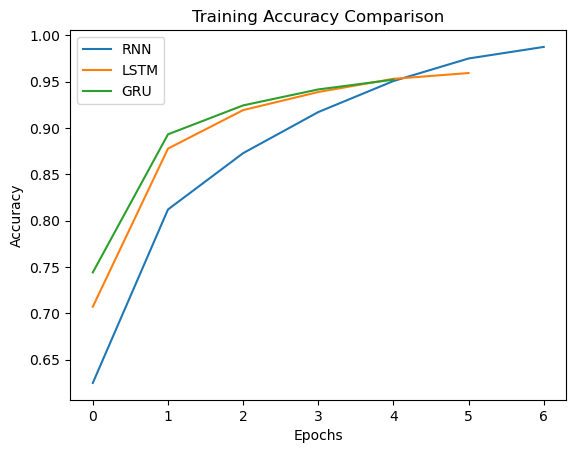

In [21]:

# ------------------------------------------
# 8. Plot Accuracy Comparison
# ------------------------------------------
plt.figure()

for m in models:
    plt.plot(history[m].history['accuracy'], label=m)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


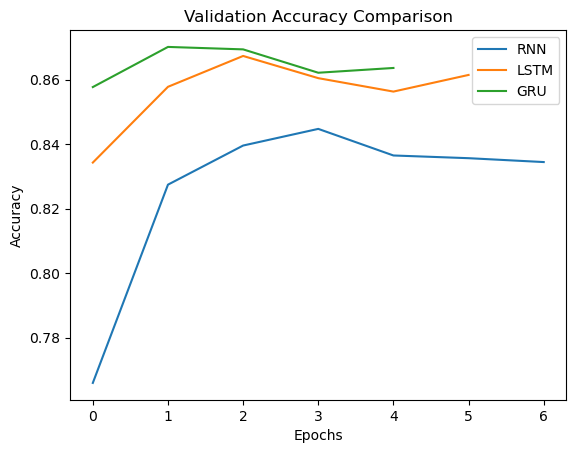

In [22]:

# ------------------------------------------
# 9. Plot Validation Accuracy
# ------------------------------------------
plt.figure()

for m in models:
    plt.plot(history[m].history['val_accuracy'], label=m)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


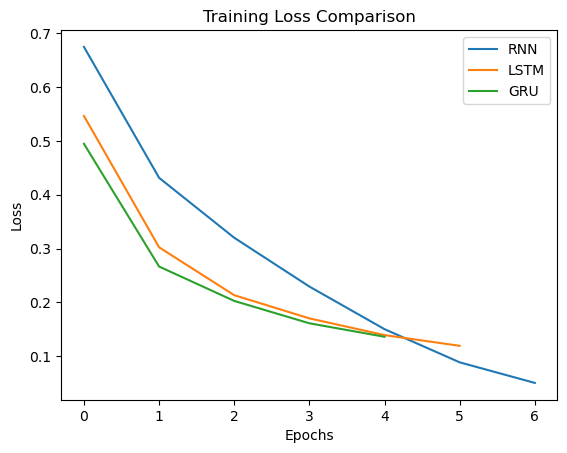

In [23]:

# ------------------------------------------
# 10. Plot Loss Comparison
# ------------------------------------------
plt.figure()

for m in models:
    plt.plot(history[m].history['loss'], label=m)

plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()